In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/food_delivery_cleaned.csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully!
Rows: 11867
Columns: 42


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11867 entries, 0 to 11866
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order ID                11867 non-null  int64  
 1   Order Amount (INR)      11867 non-null  int64  
 2   Delivery Time (mins)    11867 non-null  int64  
 3   Order Date              11867 non-null  str    
 4   Rating                  11867 non-null  float64
 5   Number of Items         11867 non-null  int64  
 6   Delivery Distance (km)  11867 non-null  float64
 7   Delivery Agent ID       11867 non-null  int64  
 8   Order Status            11867 non-null  str    
 9   Payment Method          11867 non-null  str    
 10  Tip Amount (INR)        11867 non-null  int64  
 11  Promo Code Applied      11867 non-null  str    
 12  Has Free Delivery       11867 non-null  str    
 13  res_id                  11867 non-null  int64  
 14  name                    11867 non-null  str    
 

In [4]:
df.head()

,Order ID,Order Amount (INR),Delivery Time (mins),Order Date,Rating,Number of Items,Delivery Distance (km),Delivery Agent ID,Order Status,Payment Method,...,area,Month,Year,Day,Quarter,Is_Delivered,Is_Cancelled,Has_Promo,Free_Delivery,Completed_Revenue
0,1,1930,32,2023-04-30,4.6,9,9.200017,995,Cancelled,Debit Card,...,38863,April,2023,Sunday,2,0,1,0,0,0
1,2,371,84,2023-01-06,2.7,1,8.175074,941,Cancelled,UPI,...,240928,January,2023,Friday,1,0,1,1,0,0
2,3,1389,82,2024-02-18,3.9,5,13.280443,469,Delivered,Debit Card,...,130058,February,2024,Sunday,1,1,0,0,1,1389
3,4,329,50,2023-07-06,1.9,1,11.892893,329,In-Transit,UPI,...,1484,July,2023,Thursday,3,0,0,1,0,0
4,5,400,19,2024-06-21,3.4,4,2.570476,172,Cancelled,Credit Card,...,342239,June,2024,Friday,2,0,1,0,1,0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order ID,11867.0,5.011139e+03,2.882864e+03,1.000000,2.511500e+03,5.014000e+03,7.498500e+03,1.000000e+04
Order Amount (INR),11867.0,1.579446e+03,8.257552e+02,150.000000,8.620000e+02,1.583000e+03,2.289000e+03,2.999000e+03
Delivery Time (mins),11867.0,4.953737e+01,2.320786e+01,10.000000,2.900000e+01,5.000000e+01,7.000000e+01,8.900000e+01
Rating,11867.0,3.003961e+00,1.160899e+00,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
Number of Items,11867.0,5.016516e+00,2.593682e+00,1.000000,3.000000e+00,5.000000e+00,7.000000e+00,9.000000e+00
Delivery Distance (km),11867.0,7.645786e+00,4.208160e+00,0.500953,3.914614e+00,7.624337e+00,1.125355e+01,1.499901e+01
Delivery Agent ID,11867.0,5.473130e+02,2.612487e+02,100.000000,3.170000e+02,5.520000e+02,7.770000e+02,9.980000e+02
Tip Amount (INR),11867.0,9.900329e+01,5.792771e+01,0.000000,4.900000e+01,9.900000e+01,1.490000e+02,1.990000e+02
res_id,11867.0,1.275348e+07,8.276042e+06,89.000000,2.501013e+06,1.866492e+07,1.885824e+07,1.915932e+07
latitude,11867.0,2.132860e+01,6.572241e+00,0.000000,1.748316e+01,2.230939e+01,2.648373e+01,3.408412e+01


In [6]:
total_orders = len(df)

delivered_orders = (df["Order Status"] == "Delivered").sum()

cancelled_orders = (df["Order Status"] == "Cancelled").sum()

in_transit_orders = (df["Order Status"] == "In-Transit").sum()

gross_order_value = df["Order Amount (INR)"].sum()

completed_revenue = df["Completed_Revenue"].sum()

average_order_value = df["Order Amount (INR)"].mean()

average_delivery_time = df["Delivery Time (mins)"].mean()

average_rating = df["Rating"].mean()

total_tips = df["Tip Amount (INR)"].sum()

delivery_success_rate = delivered_orders / total_orders * 100

cancellation_rate = cancelled_orders / total_orders * 100

print("========== BUSINESS KPIs ==========")
print(f"Total Orders: {total_orders:,}")
print(f"Delivered Orders: {delivered_orders:,}")
print(f"Cancelled Orders: {cancelled_orders:,}")
print(f"In-Transit Orders: {in_transit_orders:,}")
print(f"Gross Order Value: ₹{gross_order_value:,.2f}")
print(f"Completed Revenue: ₹{completed_revenue:,.2f}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Average Delivery Time: {average_delivery_time:.2f} mins")
print(f"Average Rating: {average_rating:.2f}")
print(f"Total Tips: ₹{total_tips:,.2f}")
print(f"Delivery Success Rate: {delivery_success_rate:.2f}%")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")

========== BUSINESS KPIs ==========
Total Orders: 11,867
Delivered Orders: 4,018
Cancelled Orders: 3,838
In-Transit Orders: 4,011
Gross Order Value: ₹18,743,281.00
Completed Revenue: ₹6,360,494.00
Average Order Value: ₹1,579.45
Average Delivery Time: 49.54 mins
Average Rating: 3.00
Total Tips: ₹1,174,872.00
Delivery Success Rate: 33.86%
Cancellation Rate: 32.34%


In [7]:
status_counts = df["Order Status"].value_counts()

print(status_counts)

Order Status
Delivered     4018
In-Transit    4011
Cancelled     3838
Name: count, dtype: int64


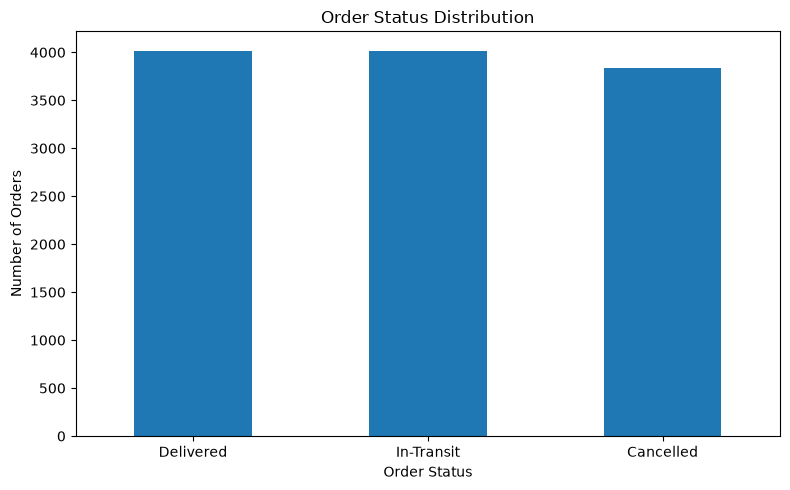

In [8]:
plt.figure(figsize=(8, 5))

status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [9]:
revenue_by_status = (
    df.groupby("Order Status")["Order Amount (INR)"]
      .sum()
      .sort_values(ascending=False)
)

print(revenue_by_status)

Order Status
Delivered     6360494
In-Transit    6292400
Cancelled     6090387
Name: Order Amount (INR), dtype: int64


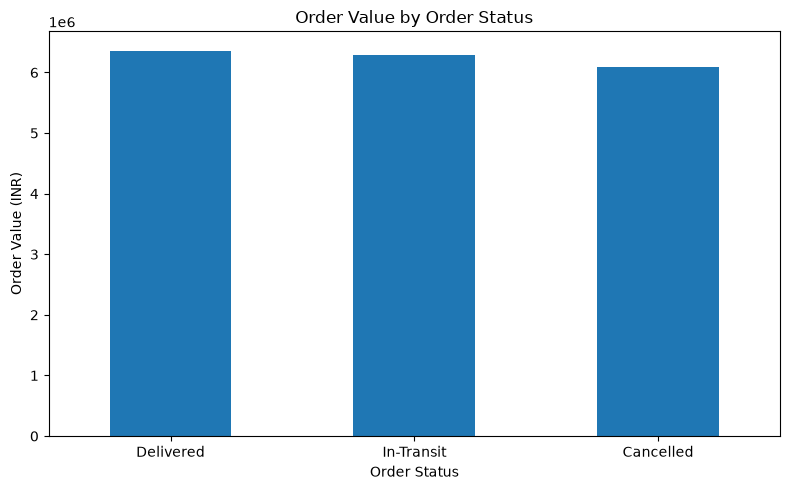

In [10]:
plt.figure(figsize=(8, 5))

revenue_by_status.plot(kind="bar")

plt.title("Order Value by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Order Value (INR)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
monthly_analysis = (
    df.groupby(["Year", "Month"])
      .agg(
          Orders=("Order ID", "count"),
          Revenue=("Completed_Revenue", "sum"),
          Average_Order_Value=("Order Amount (INR)", "mean")
      )
      .reset_index()
)

monthly_analysis

,Year,Month,Orders,Revenue,Average_Order_Value
0,2023,April,587,266063,1520.103918
1,2023,August,562,314194,1561.387900
2,2023,December,529,305649,1607.396975
3,2023,February,491,289852,1564.861507
4,2023,January,584,264077,1505.167808
5,2023,July,611,327002,1555.743044
6,2023,June,559,296831,1532.969589
7,2023,March,535,293401,1638.848598
8,2023,May,598,360492,1603.525084
9,2023,November,518,290646,1563.003861


In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Month_Number"] = df["Order Date"].dt.month

In [13]:
print(df["Order Date"].dtype)
print(df["Month_Number"].unique())

datetime64[us]
[ 4  1  2  7  6  8  5  9 10 11  3 12]


In [14]:
monthly_revenue = (
    df.groupby(["Year", "Month_Number"])["Completed_Revenue"]
      .sum()
      .reset_index()
      .sort_values(["Year", "Month_Number"])
)

monthly_revenue

,Year,Month_Number,Completed_Revenue
0,2023,1,264077
1,2023,2,289852
2,2023,3,293401
3,2023,4,266063
4,2023,5,360492
5,2023,6,296831
6,2023,7,327002
7,2023,8,314194
8,2023,9,290862
9,2023,10,284516


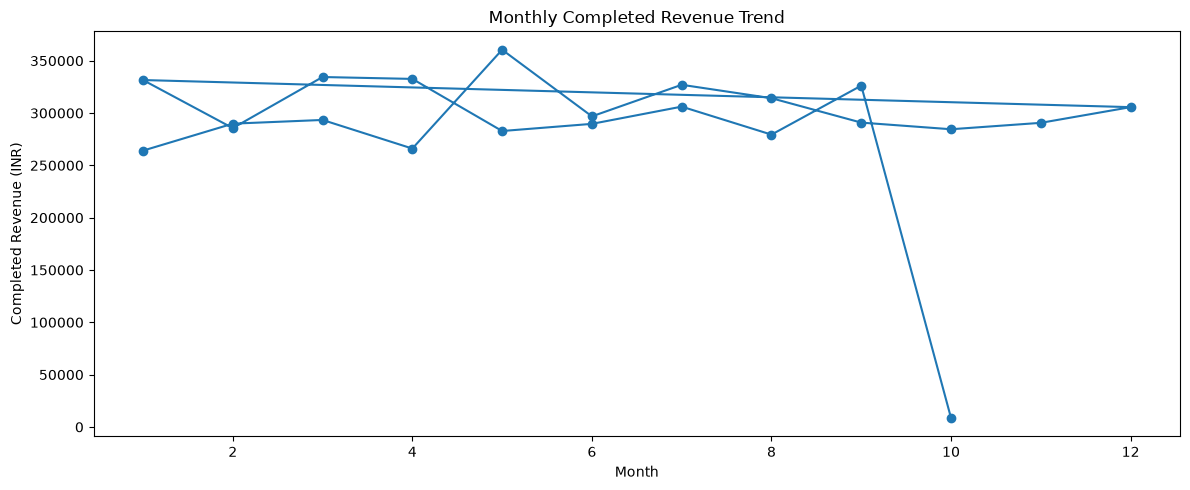

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["Month_Number"],
    monthly_revenue["Completed_Revenue"],
    marker="o"
)

plt.title("Monthly Completed Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Completed Revenue (INR)")

plt.tight_layout()
plt.show()

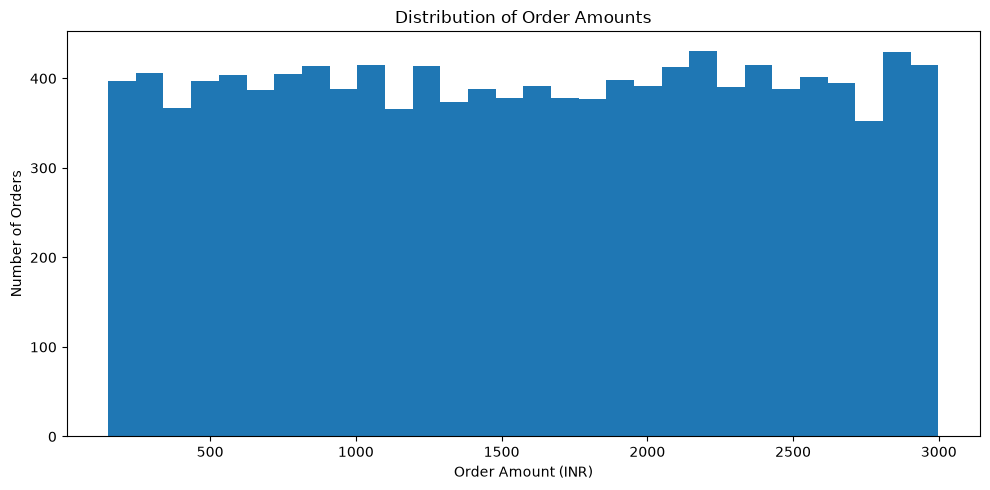

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(df["Order Amount (INR)"], bins=30)

plt.title("Distribution of Order Amounts")
plt.xlabel("Order Amount (INR)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [17]:
print("Minimum Order Amount:", df["Order Amount (INR)"].min())
print("Maximum Order Amount:", df["Order Amount (INR)"].max())
print("Average Order Amount:", df["Order Amount (INR)"].mean())
print("Median Order Amount:", df["Order Amount (INR)"].median())

Minimum Order Amount: 150
Maximum Order Amount: 2999
Average Order Amount: 1579.4456054605207
Median Order Amount: 1583.0


In [18]:
items_analysis = (
    df.groupby("Number of Items")
      .agg(
          Orders=("Order ID", "count"),
          Average_Order_Value=("Order Amount (INR)", "mean"),
          Total_Revenue=("Completed_Revenue", "sum")
      )
      .reset_index()
)

items_analysis

,Number of Items,Orders,Average_Order_Value,Total_Revenue
0,1,1298,1584.138675,712234
1,2,1337,1556.577412,728178
2,3,1335,1601.358052,742852
3,4,1311,1584.463005,712212
4,5,1304,1581.549080,700043
5,6,1232,1616.959416,665265
6,7,1354,1591.315362,703229
7,8,1344,1511.803571,674078
8,9,1352,1590.193787,722403


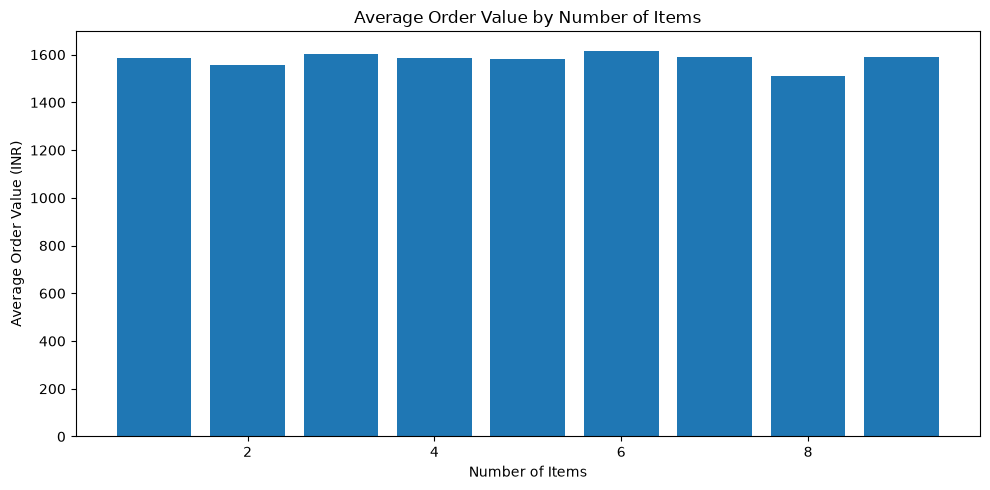

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(
    items_analysis["Number of Items"],
    items_analysis["Average_Order_Value"]
)

plt.title("Average Order Value by Number of Items")
plt.xlabel("Number of Items")
plt.ylabel("Average Order Value (INR)")

plt.tight_layout()
plt.show()

In [20]:
promo_analysis = (
    df.groupby("Promo Code Applied")
      .agg(
          Orders=("Order ID", "count"),
          Average_Order_Value=("Order Amount (INR)", "mean"),
          Completed_Revenue=("Completed_Revenue", "sum"),
          Average_Rating=("Rating", "mean")
      )
      .reset_index()
)

promo_analysis

,Promo Code Applied,Orders,Average_Order_Value,Completed_Revenue,Average_Rating
0,No,5815,1577.265004,3141159,2.985348
1,Yes,6052,1581.540813,3219335,3.021844


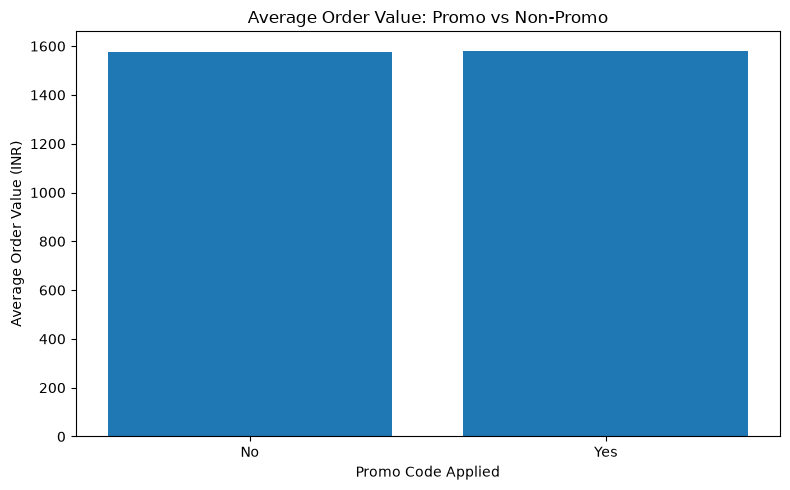

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    promo_analysis["Promo Code Applied"],
    promo_analysis["Average_Order_Value"]
)

plt.title("Average Order Value: Promo vs Non-Promo")
plt.xlabel("Promo Code Applied")
plt.ylabel("Average Order Value (INR)")

plt.tight_layout()
plt.show()

In [22]:
free_delivery_analysis = (
    df.groupby("Has Free Delivery")
      .agg(
          Orders=("Order ID", "count"),
          Average_Order_Value=("Order Amount (INR)", "mean"),
          Completed_Revenue=("Completed_Revenue", "sum"),
          Average_Delivery_Time=("Delivery Time (mins)", "mean")
      )
      .reset_index()
)

free_delivery_analysis

,Has Free Delivery,Orders,Average_Order_Value,Completed_Revenue,Average_Delivery_Time
0,No,5960,1578.696812,3128711,49.938926
1,Yes,5907,1580.201117,3231783,49.132216


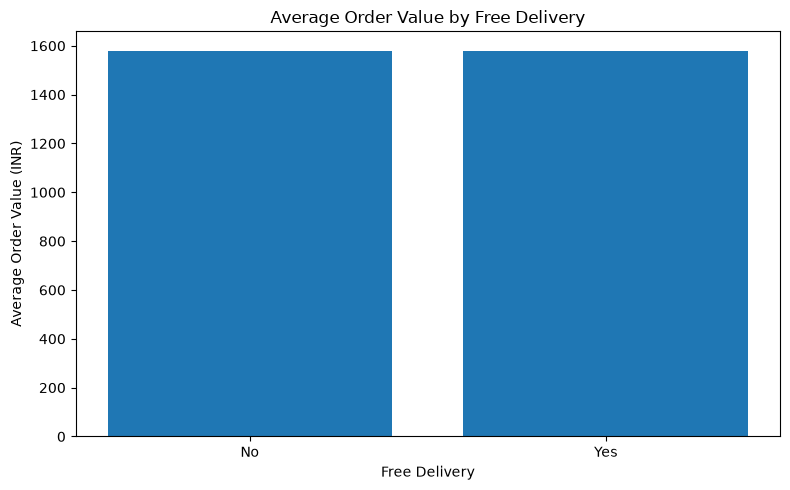

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    free_delivery_analysis["Has Free Delivery"],
    free_delivery_analysis["Average_Order_Value"]
)

plt.title("Average Order Value by Free Delivery")
plt.xlabel("Free Delivery")
plt.ylabel("Average Order Value (INR)")

plt.tight_layout()
plt.show()

In [24]:
payment_analysis = (
    df.groupby("Payment Method")
      .agg(
          Orders=("Order ID", "count"),
          Average_Order_Value=("Order Amount (INR)", "mean"),
          Completed_Revenue=("Completed_Revenue", "sum")
      )
      .sort_values("Completed_Revenue", ascending=False)
      .reset_index()
)

payment_analysis

,Payment Method,Orders,Average_Order_Value,Completed_Revenue
0,Debit Card,2352,1569.420068,1292096
1,Net Banking,2353,1582.145346,1291937
2,Cash,2386,1588.100168,1262379
3,UPI,2419,1580.811492,1262242
4,Credit Card,2357,1576.591854,1251840


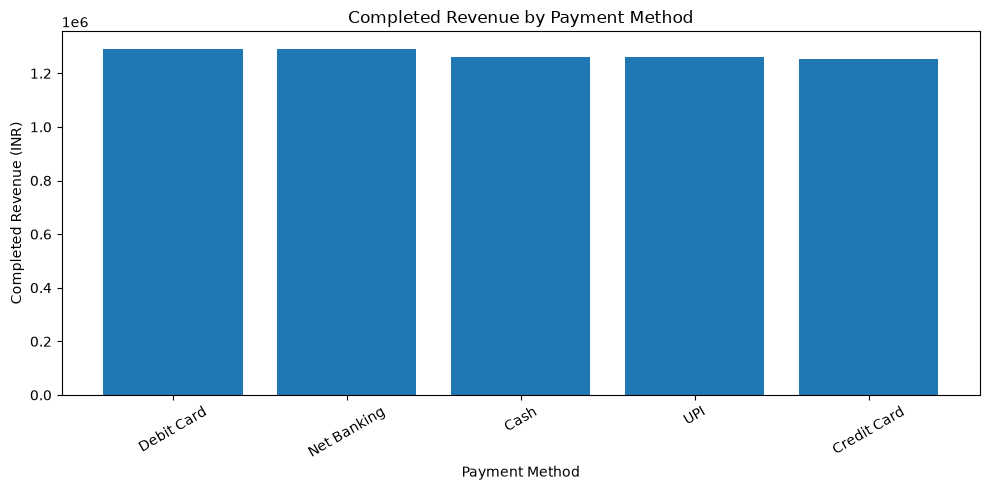

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    payment_analysis["Payment Method"],
    payment_analysis["Completed_Revenue"]
)

plt.title("Completed Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Completed Revenue (INR)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 13. Restaurant Performance Analysis

In [26]:
restaurant_analysis = (
    df.groupby("name")
    .agg(
        Total_Orders=("Order ID", "count"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Avg_Rating=("Rating", "mean"),
        Avg_Delivery_Time=("Delivery Time (mins)", "mean"),
        Total_Revenue=("Completed_Revenue", "sum"),
        Avg_Distance=("Delivery Distance (km)", "mean")
    )
    .sort_values("Total_Orders", ascending=False)
)

restaurant_analysis.head(10)

,Total_Orders,Avg_Order_Value,Avg_Rating,Avg_Delivery_Time,Total_Revenue,Avg_Distance
name,,,,,,
Domino's Pizza,66,1558.075758,2.892424,54.196970,48110,7.677496
KFC,61,1384.426230,3.050820,51.508197,25153,7.963544
Cafe Coffee Day,55,1534.654545,2.929091,51.581818,21819,7.064983
Subway,46,1243.500000,3.078261,56.739130,18058,7.101645
Candy and Green,40,1519.600000,2.020000,55.000000,23360,9.008166
Burger King,37,1569.243243,2.835135,34.432432,28822,7.586345
McDonald's,35,1625.428571,3.402857,44.857143,22813,8.660696
Keventers,32,1723.125000,2.937500,55.968750,25903,8.086136
Baskin Robbins,31,1547.258065,3.125806,56.645161,14179,8.137050


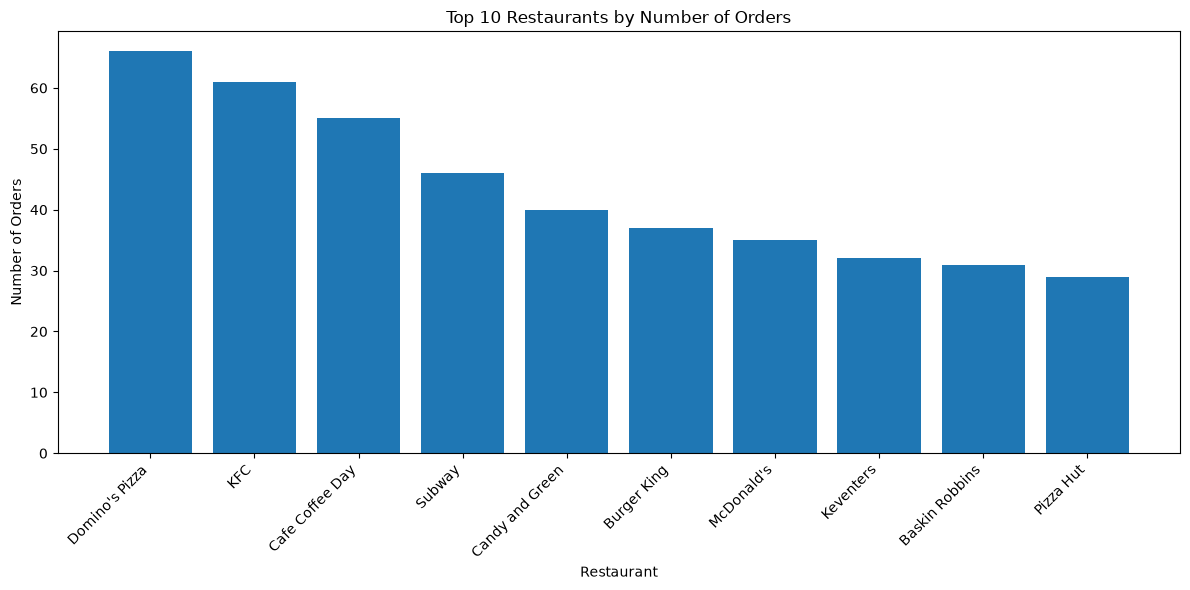

In [27]:
top_restaurants = restaurant_analysis.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_restaurants.index,
    top_restaurants["Total_Orders"]
)

plt.title("Top 10 Restaurants by Number of Orders")
plt.xlabel("Restaurant")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

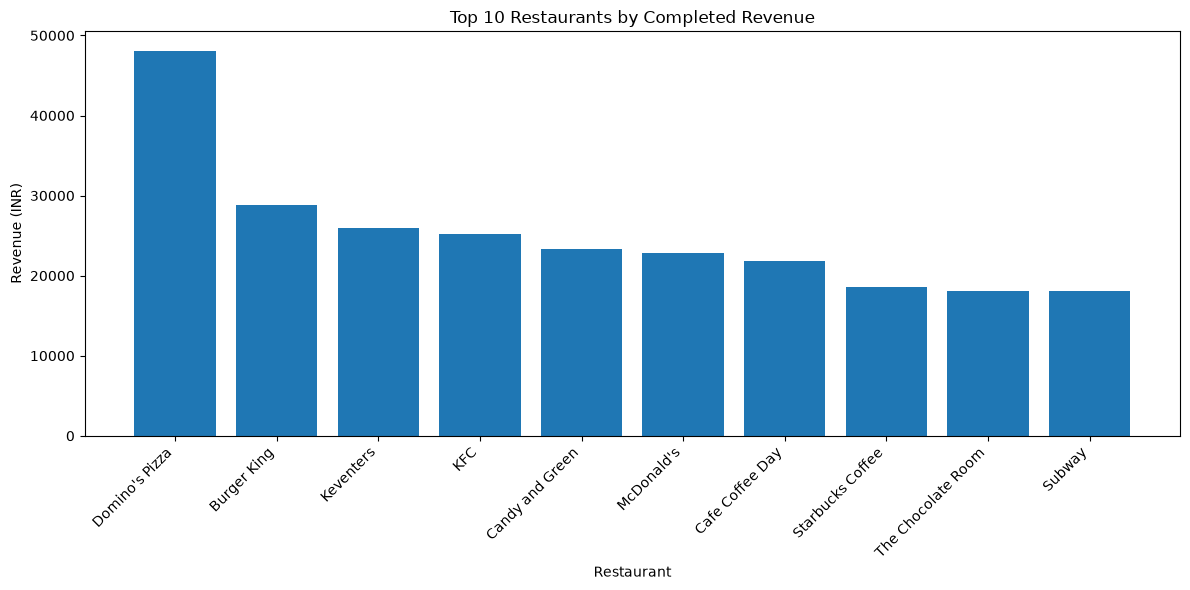

In [28]:
top_revenue = (
    restaurant_analysis
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_revenue.index,
    top_revenue["Total_Revenue"]
)

plt.title("Top 10 Restaurants by Completed Revenue")
plt.xlabel("Restaurant")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

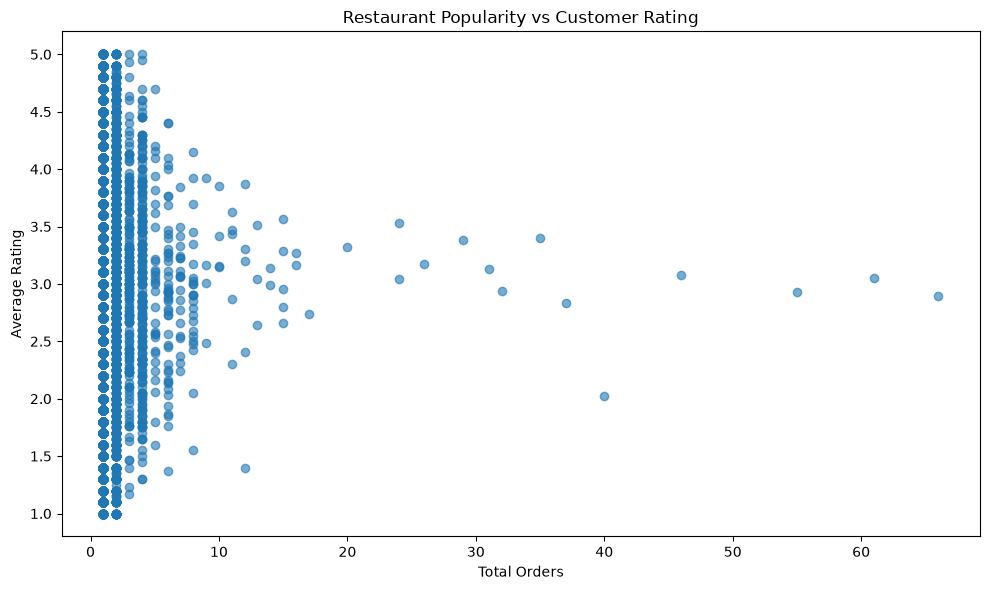

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(
    restaurant_analysis["Total_Orders"],
    restaurant_analysis["Avg_Rating"],
    alpha=0.6
)

plt.title("Restaurant Popularity vs Customer Rating")
plt.xlabel("Total Orders")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [30]:
problem_restaurants = restaurant_analysis[
    (restaurant_analysis["Total_Orders"] >= restaurant_analysis["Total_Orders"].quantile(0.75)) &
    (restaurant_analysis["Avg_Rating"] < 3)
].sort_values("Total_Orders", ascending=False)

problem_restaurants.head(10)

,Total_Orders,Avg_Order_Value,Avg_Rating,Avg_Delivery_Time,Total_Revenue,Avg_Distance
name,,,,,,
Domino's Pizza,66,1558.075758,2.892424,54.196970,48110,7.677496
Cafe Coffee Day,55,1534.654545,2.929091,51.581818,21819,7.064983
Candy and Green,40,1519.600000,2.020000,55.000000,23360,9.008166
Burger King,37,1569.243243,2.835135,34.432432,28822,7.586345
Keventers,32,1723.125000,2.937500,55.968750,25903,8.086136
Mainland China,17,1523.705882,2.741176,45.823529,9570,8.565774
Loft,15,1974.933333,2.660000,52.866667,4308,4.430639
Cream Stone,15,1252.933333,2.800000,38.066667,7333,9.773275
Barbeque Nation,15,1731.000000,2.960000,48.200000,15539,7.255387


In [31]:
order_size_analysis = (
    df.groupby("Number of Items")
    .agg(
        Total_Orders=("Order ID", "count"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Avg_Delivery_Time=("Delivery Time (mins)", "mean"),
        Avg_Rating=("Rating", "mean")
    )
    .sort_index()
)

order_size_analysis

,Total_Orders,Avg_Order_Value,Avg_Delivery_Time,Avg_Rating
Number of Items,,,,
1,1298,1584.138675,49.815100,2.942450
2,1337,1556.577412,48.741212,2.938220
3,1335,1601.358052,49.134831,3.026442
4,1311,1584.463005,49.445461,3.031121
5,1304,1581.549080,50.139571,3.054678
6,1232,1616.959416,49.235390,2.954545
7,1354,1591.315362,50.209010,3.025702
8,1344,1511.803571,48.289435,3.025670
9,1352,1590.193787,50.806953,3.032249


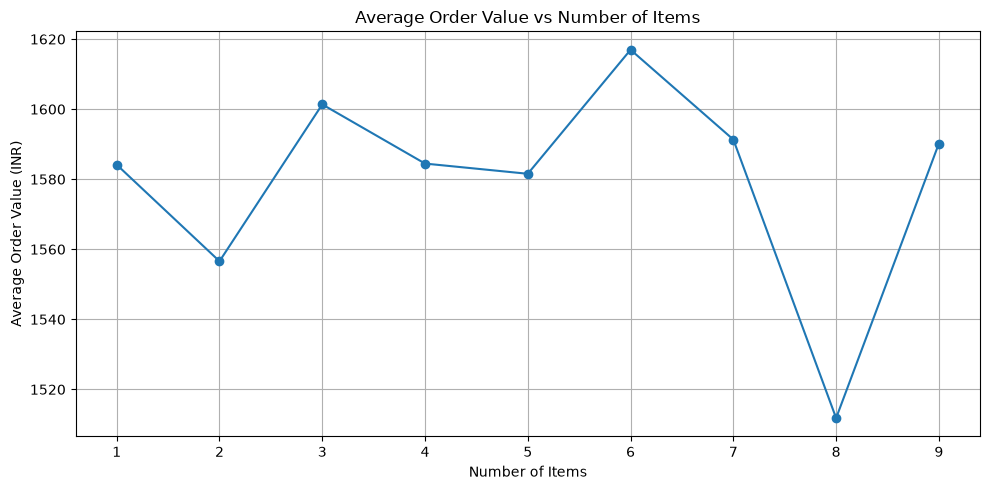

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    order_size_analysis.index,
    order_size_analysis["Avg_Order_Value"],
    marker="o"
)

plt.title("Average Order Value vs Number of Items")
plt.xlabel("Number of Items")
plt.ylabel("Average Order Value (INR)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [33]:
delivery_analysis = (
    df.groupby("Delivery Distance (km)")
    .agg(
        Total_Orders=("Order ID", "count"),
        Avg_Delivery_Time=("Delivery Time (mins)", "mean"),
        Avg_Rating=("Rating", "mean"),
        Avg_Order_Value=("Order Amount (INR)", "mean")
    )
    .sort_index()
)

delivery_analysis.head(15)

,Total_Orders,Avg_Delivery_Time,Avg_Rating,Avg_Order_Value
Delivery Distance (km),,,,
0.500953,1,18.0,1.1,1921.0
0.501268,1,74.0,4.7,2509.0
0.508130,1,24.0,1.1,1348.0
0.509624,1,33.0,4.6,203.0
0.511145,1,37.0,2.8,359.0
0.511637,1,30.0,3.6,1803.0
0.512434,1,66.0,1.5,2248.0
0.515593,1,61.0,2.8,1746.0
0.515824,1,47.0,3.0,1899.0


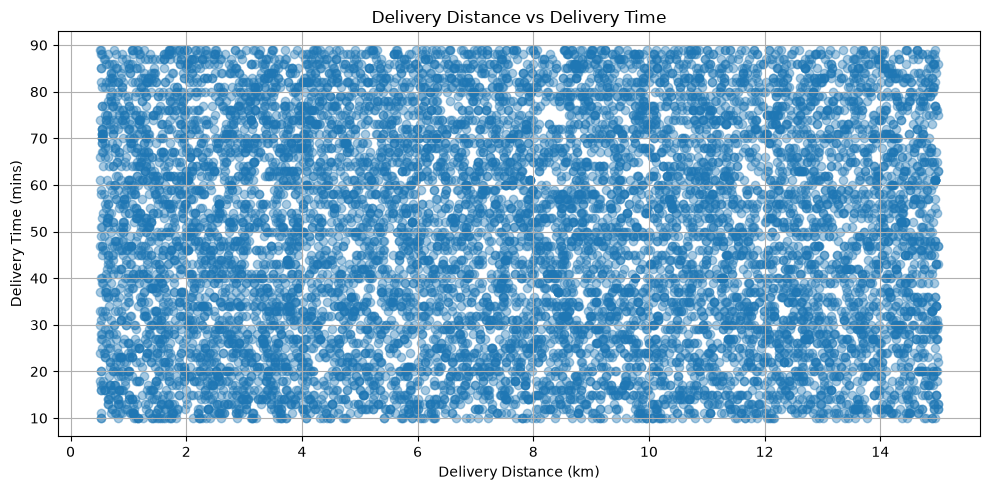

In [34]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["Delivery Distance (km)"],
    df["Delivery Time (mins)"],
    alpha=0.4
)

plt.title("Delivery Distance vs Delivery Time")
plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Time (mins)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [35]:
distance_time_corr = df[
    ["Delivery Distance (km)", "Delivery Time (mins)"]
].corr()

distance_time_corr

,Delivery Distance (km),Delivery Time (mins)
Delivery Distance (km),1.000000,-0.002978
Delivery Time (mins),-0.002978,1.000000


In [36]:
status_analysis = (
    df.groupby("Order Status")
    .agg(
        Total_Orders=("Order ID", "count"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Avg_Delivery_Time=("Delivery Time (mins)", "mean"),
        Avg_Distance=("Delivery Distance (km)", "mean"),
        Avg_Rating=("Rating", "mean")
    )
    .sort_values("Total_Orders", ascending=False)
)

status_analysis

,Total_Orders,Avg_Order_Value,Avg_Delivery_Time,Avg_Distance,Avg_Rating
Order Status,,,,,
Delivered,4018,1583.000000,49.728721,7.729255,2.953534
In-Transit,4011,1568.785839,49.559461,7.664221,3.021366
Cancelled,3838,1586.864773,49.313966,7.539135,3.038562


In [37]:
total_orders = len(df)

cancelled_orders = (
    df["Order Status"] == "Cancelled"
).sum()

cancellation_rate = (cancelled_orders / total_orders) * 100

print("Total Orders:", total_orders)
print("Cancelled Orders:", cancelled_orders)
print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Total Orders: 11867
Cancelled Orders: 3838
Cancellation Rate: 32.34%


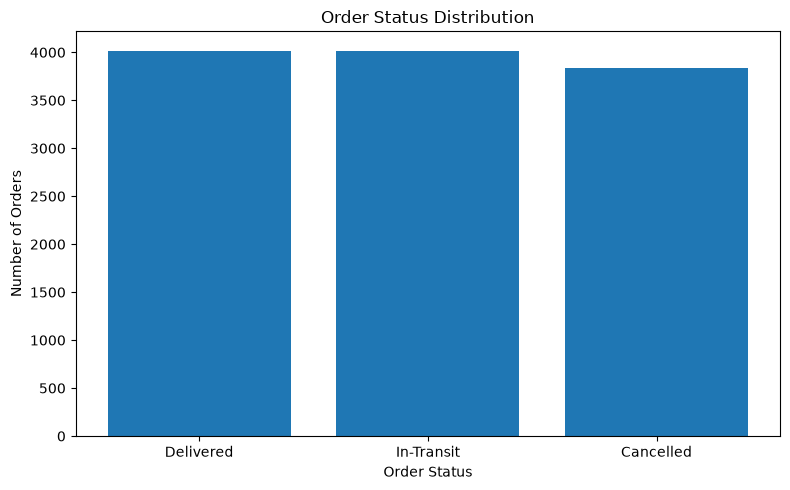

In [38]:
status_counts = df["Order Status"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [39]:
cancelled_vs_delivered = (
    df[df["Order Status"].isin(["Cancelled", "Delivered"])]
    .groupby("Order Status")
    .agg(
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Avg_Delivery_Time=("Delivery Time (mins)", "mean"),
        Avg_Distance=("Delivery Distance (km)", "mean"),
        Avg_Rating=("Rating", "mean")
    )
)

cancelled_vs_delivered

,Avg_Order_Value,Avg_Delivery_Time,Avg_Distance,Avg_Rating
Order Status,,,,
Cancelled,1586.864773,49.313966,7.539135,3.038562
Delivered,1583.000000,49.728721,7.729255,2.953534


In [40]:
df["Order_Value_Segment"] = pd.cut(
    df["Order Amount (INR)"],
    bins=[0, 500, 1500, float("inf")],
    labels=["Low Value", "Medium Value", "High Value"]
)

spending_analysis = (
    df.groupby("Order_Value_Segment", observed=False)
    .agg(
        Orders=("Order ID", "count"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Completed_Revenue=("Completed_Revenue", "sum"),
        Avg_Items=("Number of Items", "mean"),
        Avg_Rating=("Rating", "mean")
    )
    .reset_index()
)

spending_analysis

,Order_Value_Segment,Orders,Avg_Order_Value,Completed_Revenue,Avg_Items,Avg_Rating
0,Low Value,1446,323.587828,165708,5.005533,2.982019
1,Medium Value,4162,997.369534,1375991,5.044690,3.002331
2,High Value,6259,2256.641796,4818795,5.000320,3.010113


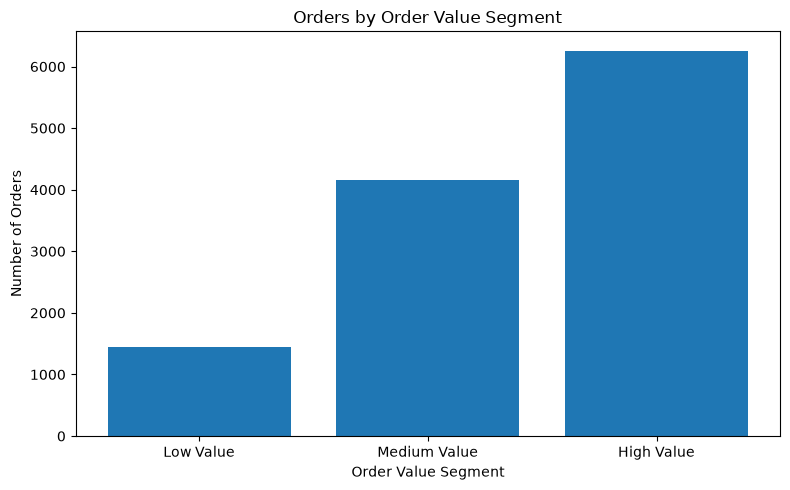

In [41]:
plt.figure(figsize=(8, 5))

plt.bar(
    spending_analysis["Order_Value_Segment"],
    spending_analysis["Orders"]
)

plt.title("Orders by Order Value Segment")
plt.xlabel("Order Value Segment")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [42]:
promo_deep_analysis = (
    df.groupby("Promo Code Applied")
    .agg(
        Orders=("Order ID", "count"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Completed_Revenue=("Completed_Revenue", "sum"),
        Avg_Items=("Number of Items", "mean"),
        Avg_Rating=("Rating", "mean"),
        Avg_Delivery_Time=("Delivery Time (mins)", "mean")
    )
    .reset_index()
)

promo_deep_analysis

,Promo Code Applied,Orders,Avg_Order_Value,Completed_Revenue,Avg_Items,Avg_Rating,Avg_Delivery_Time
0,No,5815,1577.265004,3141159,4.968358,2.985348,49.259501
1,Yes,6052,1581.540813,3219335,5.062789,3.021844,49.804362


In [43]:
promo_cancellation = (
    df.assign(
        Cancelled=df["Order Status"].eq("Cancelled").astype(int)
    )
    .groupby("Promo Code Applied")
    .agg(
        Orders=("Order ID", "count"),
        Cancellation_Rate=("Cancelled", "mean")
    )
    .reset_index()
)

promo_cancellation["Cancellation_Rate"] *= 100

promo_cancellation

,Promo Code Applied,Orders,Cancellation_Rate
0,No,5815,33.172829
1,Yes,6052,31.543291


In [44]:
free_delivery_analysis = (
    df.groupby("Has Free Delivery")
    .agg(
        Orders=("Order ID", "count"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Completed_Revenue=("Completed_Revenue", "sum"),
        Avg_Items=("Number of Items", "mean"),
        Avg_Delivery_Time=("Delivery Time (mins)", "mean")
    )
    .reset_index()
)

free_delivery_analysis

,Has Free Delivery,Orders,Avg_Order_Value,Completed_Revenue,Avg_Items,Avg_Delivery_Time
0,No,5960,1578.696812,3128711,4.979362,49.938926
1,Yes,5907,1580.201117,3231783,5.054004,49.132216


## 18. Geographic & City Performance Analysis

In [45]:
city_analysis = (
    df.groupby("city")
    .agg(
        Total_Orders=("Order ID", "count"),
        Completed_Revenue=("Completed_Revenue", "sum"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Avg_Delivery_Time=("Delivery Time (mins)", "mean"),
        Avg_Rating=("Rating", "mean"),
        Avg_Distance=("Delivery Distance (km)", "mean")
    )
    .sort_values("Completed_Revenue", ascending=False)
)

city_analysis.head(10)

,Total_Orders,Completed_Revenue,Avg_Order_Value,Avg_Delivery_Time,Avg_Rating,Avg_Distance
city,,,,,,
Chennai,791,425432,1515.118837,47.993679,2.959924,7.744035
Mumbai,710,411797,1551.638028,49.378873,2.922394,7.729242
Aurangabad,634,390570,1595.123028,45.889590,2.994322,7.672172
Bangalore,477,251281,1594.761006,50.354298,3.134591,7.704734
Pune,403,242591,1578.473945,50.483871,2.971712,7.538932
New Delhi,394,215561,1573.368020,51.956853,3.059898,7.557126
Jaipur,284,164695,1642.214789,50.133803,2.984507,7.720330
Ahmedabad,267,163646,1696.647940,49.767790,2.895506,7.811533
Kolkata,259,158041,1650.972973,49.942085,3.006178,7.728640


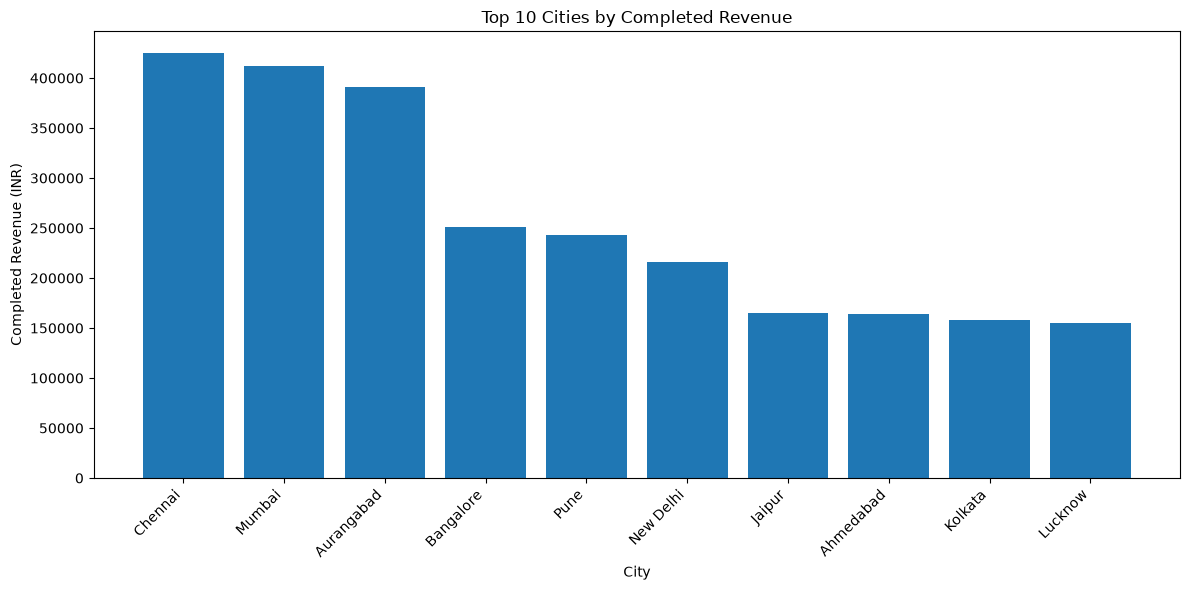

In [46]:
top_cities = city_analysis.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_cities.index,
    top_cities["Completed_Revenue"]
)

plt.title("Top 10 Cities by Completed Revenue")
plt.xlabel("City")
plt.ylabel("Completed Revenue (INR)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

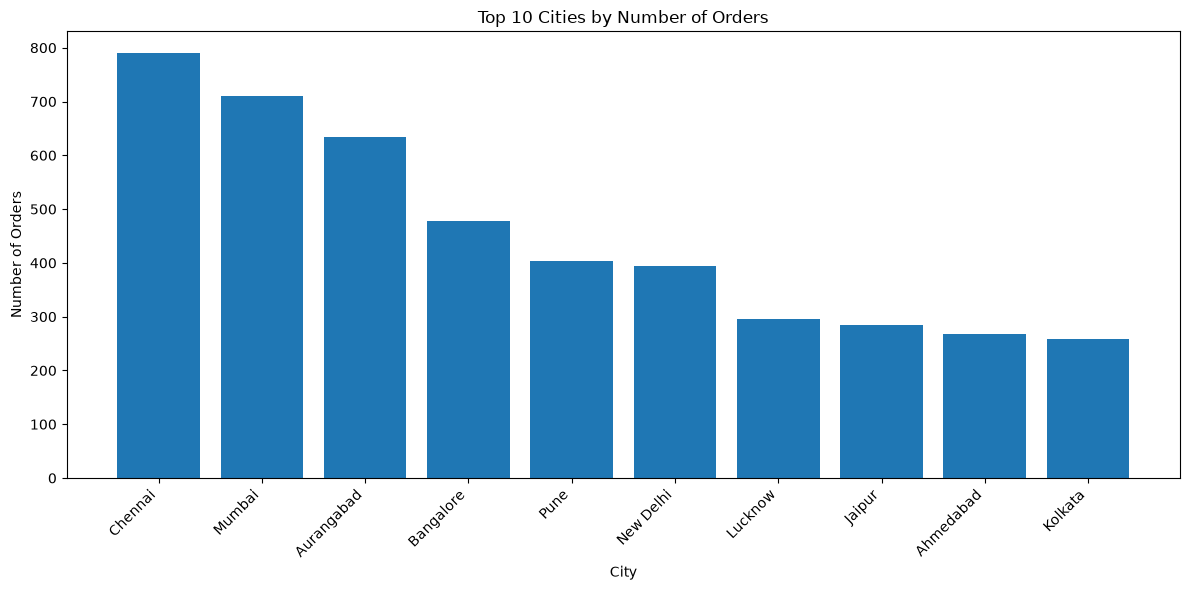

In [47]:
top_order_cities = (
    city_analysis
    .sort_values("Total_Orders", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_order_cities.index,
    top_order_cities["Total_Orders"]
)

plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [48]:
state_analysis = (
    df.groupby("state")
    .agg(
        Total_Orders=("Order ID", "count"),
        Completed_Revenue=("Completed_Revenue", "sum"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Avg_Delivery_Time=("Delivery Time (mins)", "mean"),
        Avg_Rating=("Rating", "mean")
    )
    .sort_values("Completed_Revenue", ascending=False)
)

state_analysis

,Total_Orders,Completed_Revenue,Avg_Order_Value,Avg_Delivery_Time,Avg_Rating
state,,,,,
Maharashtra,2111,1191961,1579.620559,49.334912,2.969872
Uttar Pradesh,1301,641538,1602.043812,50.681015,3.014143
Tamil Nadu,1255,637015,1535.111554,49.378486,2.956096
Gujarat,916,516854,1630.660480,49.728166,2.964629
Rajasthan,859,453854,1601.847497,49.582072,3.077881
Karnataka,702,366015,1561.581197,50.135328,3.101709
Madhya Pradesh,694,336077,1587.072046,48.613833,2.955908
Punjab,595,306344,1597.443697,50.181513,2.994958
Bihar,452,271797,1575.464602,47.097345,3.028097


In [49]:
city_cancellation = (
    df.assign(
        Cancelled=df["Order Status"].eq("Cancelled").astype(int)
    )
    .groupby("city")
    .agg(
        Total_Orders=("Order ID", "count"),
        Cancelled_Orders=("Cancelled", "sum")
    )
)

city_cancellation["Cancellation_Rate"] = (
    city_cancellation["Cancelled_Orders"] /
    city_cancellation["Total_Orders"] * 100
)

city_cancellation = city_cancellation.sort_values(
    "Cancellation_Rate",
    ascending=False
)

city_cancellation.head(10)

,Total_Orders,Cancelled_Orders,Cancellation_Rate
city,,,
Shimla,49,22,44.897959
Kharagpur,36,16,44.444444
Gorakhpur,124,54,43.548387
Udupi,14,6,42.857143
Salem,103,43,41.747573
Panchkula,27,11,40.740741
Noida,62,25,40.322581
Madurai,102,40,39.215686
Mangalore,111,43,38.738739


In [50]:
reliable_city_cancellation = city_cancellation[
    city_cancellation["Total_Orders"] >= 100
].sort_values(
    "Cancellation_Rate",
    ascending=False
)

reliable_city_cancellation.head(10)

,Total_Orders,Cancelled_Orders,Cancellation_Rate
city,,,
Gorakhpur,124,54,43.548387
Salem,103,43,41.747573
Madurai,102,40,39.215686
Mangalore,111,43,38.738739
Jammu,121,46,38.016529
Kota,127,48,37.795276
Vijayawada,139,52,37.410072
Udaipur,147,54,36.734694
Agra,185,67,36.216216


## 19. Cuisine & Restaurant Type Analysis

In [51]:
type_analysis = (
    df.groupby("type")
    .agg(
        Total_Orders=("Order ID", "count"),
        Completed_Revenue=("Completed_Revenue", "sum"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Avg_Rating=("Rating", "mean"),
        Avg_Delivery_Time=("Delivery Time (mins)", "mean")
    )
    .sort_values("Completed_Revenue", ascending=False)
)

type_analysis

,Total_Orders,Completed_Revenue,Avg_Order_Value,Avg_Rating,Avg_Delivery_Time
type,,,,,
Quick Bites,3174,1733264,1583.028986,3.024858,49.778513
Casual Dining,2774,1440781,1583.812906,3.005660,48.733958
Café,950,511921,1544.705263,3.009579,49.427368
Dessert Parlour,722,458867,1616.214681,2.893075,49.440443
Bakery,673,305045,1544.585438,3.003120,50.139673
Sweet Shop,509,279194,1586.976424,2.991552,49.532417
Beverage Shop,453,225304,1621.476821,2.984106,47.931567
Fine Dining,317,192697,1552.596215,3.134700,48.933754
Food Court,321,177199,1572.214953,3.009346,50.099688


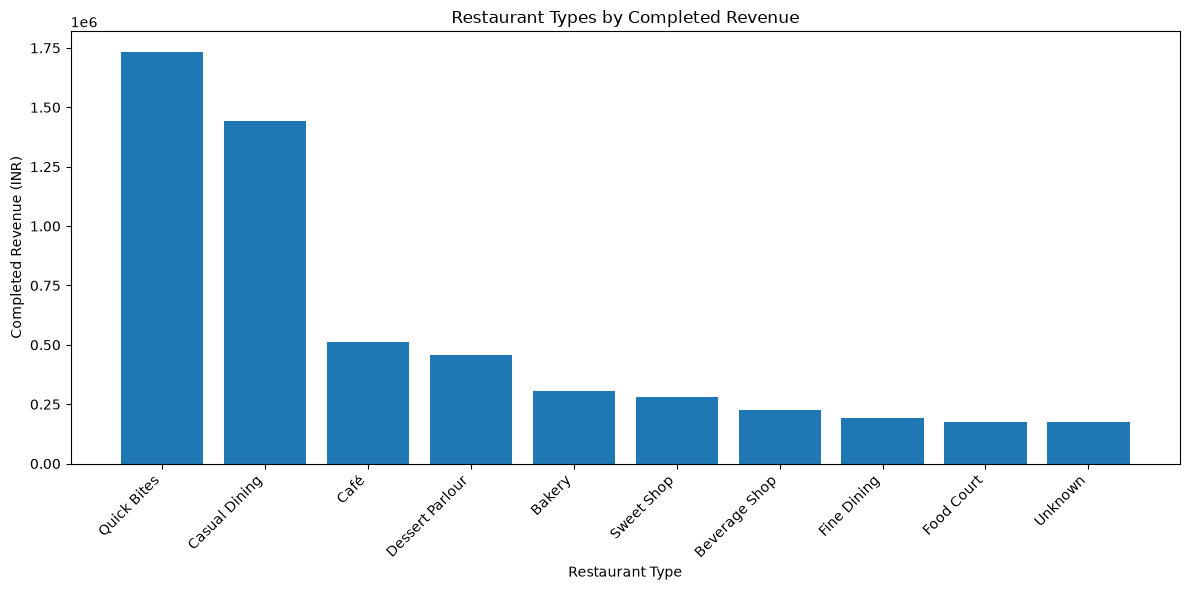

In [52]:
top_types = type_analysis.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_types.index,
    top_types["Completed_Revenue"]
)

plt.title("Restaurant Types by Completed Revenue")
plt.xlabel("Restaurant Type")
plt.ylabel("Completed Revenue (INR)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

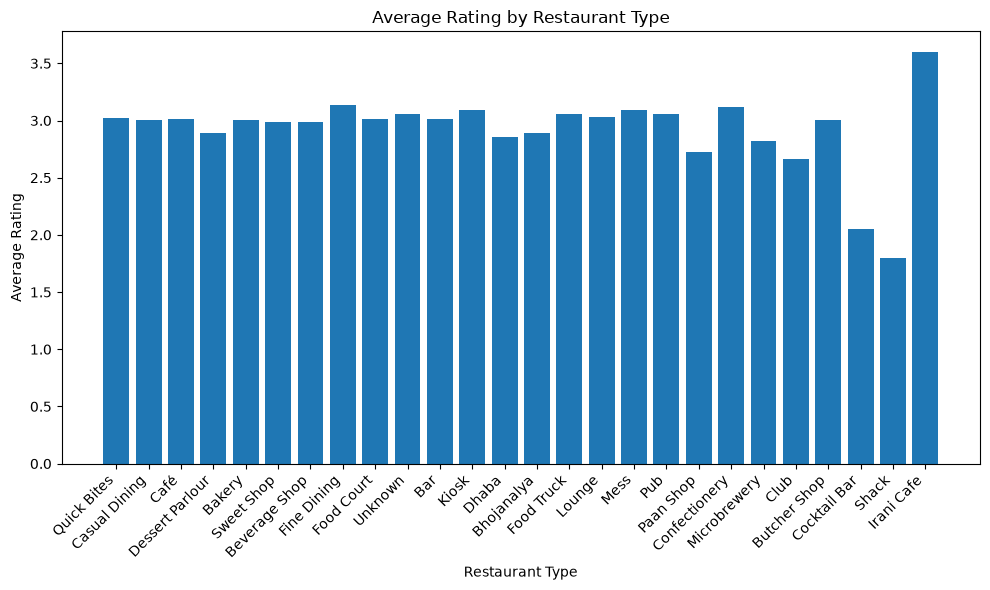

In [53]:
plt.figure(figsize=(10, 6))

plt.bar(
    type_analysis.index,
    type_analysis["Avg_Rating"]
)

plt.title("Average Rating by Restaurant Type")
plt.xlabel("Restaurant Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [54]:
cuisine_df = df.copy()

cuisine_df["Cuisine"] = cuisine_df["cuisines"].fillna("Unknown").str.split(", ")

cuisine_df = cuisine_df.explode("Cuisine")

In [55]:
cuisine_analysis = (
    cuisine_df.groupby("Cuisine")
    .agg(
        Total_Orders=("Order ID", "count"),
        Completed_Revenue=("Completed_Revenue", "sum"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Avg_Rating=("Rating", "mean")
    )
    .sort_values("Completed_Revenue", ascending=False)
)

cuisine_analysis.head(15)

,Total_Orders,Completed_Revenue,Avg_Order_Value,Avg_Rating
Cuisine,,,,
North Indian,4308,2276502,1580.154132,3.047981
Chinese,2914,1533221,1579.306108,3.033082
Fast Food,2739,1464095,1580.466229,2.984483
Desserts,1581,908314,1562.405440,2.922644
Beverages,1532,854215,1606.186031,3.006005
South Indian,1311,658789,1562.151793,3.024180
Continental,1248,616212,1549.769231,3.037901
Cafe,1017,554491,1595.770895,3.048968
Italian,969,518711,1630.884417,3.016512


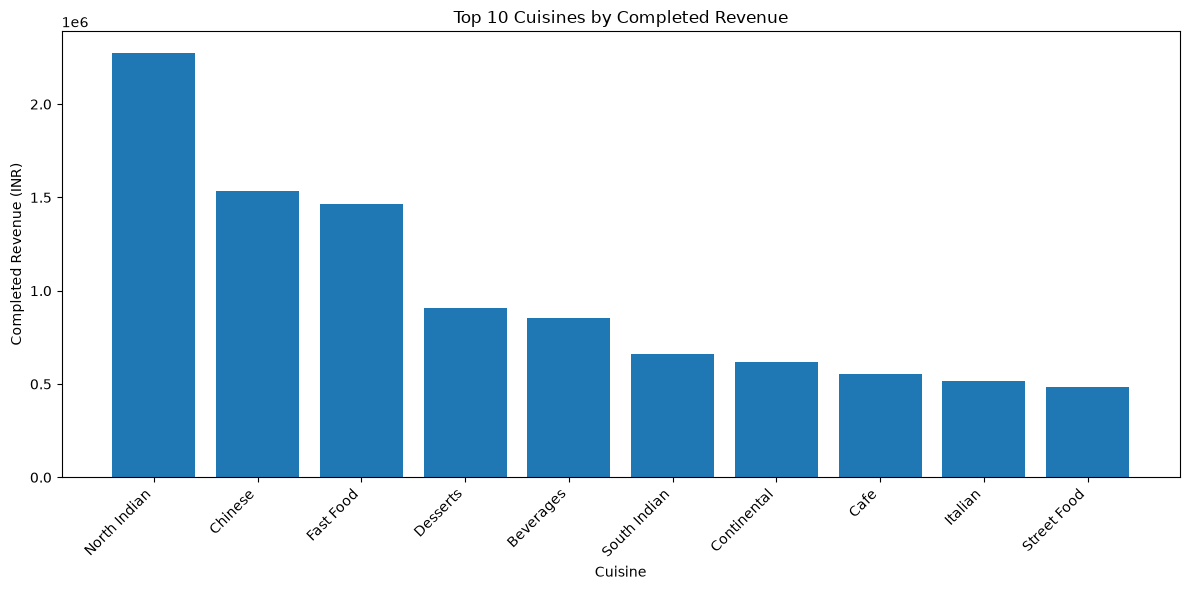

In [56]:
top_cuisines = cuisine_analysis.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_cuisines.index,
    top_cuisines["Completed_Revenue"]
)

plt.title("Top 10 Cuisines by Completed Revenue")
plt.xlabel("Cuisine")
plt.ylabel("Completed Revenue (INR)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

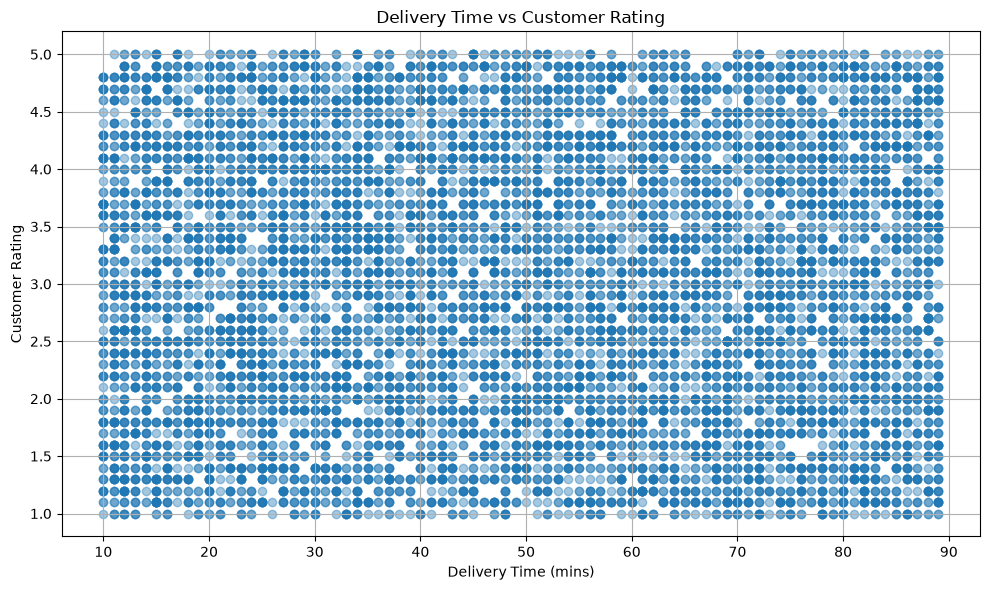

In [57]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Delivery Time (mins)"],
    df["Rating"],
    alpha=0.4
)

plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Time (mins)")
plt.ylabel("Customer Rating")
plt.grid(True)

plt.tight_layout()
plt.show()

In [58]:
delivery_rating_corr = df[
    ["Delivery Time (mins)", "Rating"]
].corr()

delivery_rating_corr

,Delivery Time (mins),Rating
Delivery Time (mins),1.000000,-0.004451
Rating,-0.004451,1.000000


In [59]:
distance_delivery_corr = df[
    ["Delivery Distance (km)", "Delivery Time (mins)"]
].corr()

distance_delivery_corr

,Delivery Distance (km),Delivery Time (mins)
Delivery Distance (km),1.000000,-0.002978
Delivery Time (mins),-0.002978,1.000000


In [60]:
order_value_items_corr = df[
    ["Order Amount (INR)", "Number of Items"]
].corr()

order_value_items_corr

,Order Amount (INR),Number of Items
Order Amount (INR),1.000000,-0.005272
Number of Items,-0.005272,1.000000


In [61]:
df["Delivery_Time_Group"] = pd.cut(
    df["Delivery Time (mins)"],
    bins=[0, 30, 45, 60, 90, float("inf")],
    labels=[
        "Under 30 mins",
        "30–45 mins",
        "45–60 mins",
        "60–90 mins",
        "90+ mins"
    ]
)

In [62]:
delivery_cancellation = (
    df.assign(
        Cancelled=df["Order Status"].eq("Cancelled").astype(int)
    )
    .groupby("Delivery_Time_Group", observed=False)
    .agg(
        Total_Orders=("Order ID", "count"),
        Cancelled_Orders=("Cancelled", "sum")
    )
)

delivery_cancellation["Cancellation_Rate"] = (
    delivery_cancellation["Cancelled_Orders"] /
    delivery_cancellation["Total_Orders"] * 100
)

delivery_cancellation

,Total_Orders,Cancelled_Orders,Cancellation_Rate
Delivery_Time_Group,,,
Under 30 mins,3148,1032,32.782719
30–45 mins,2181,719,32.966529
45–60 mins,2198,707,32.165605
60–90 mins,4340,1380,31.797235
90+ mins,0,0,NaN


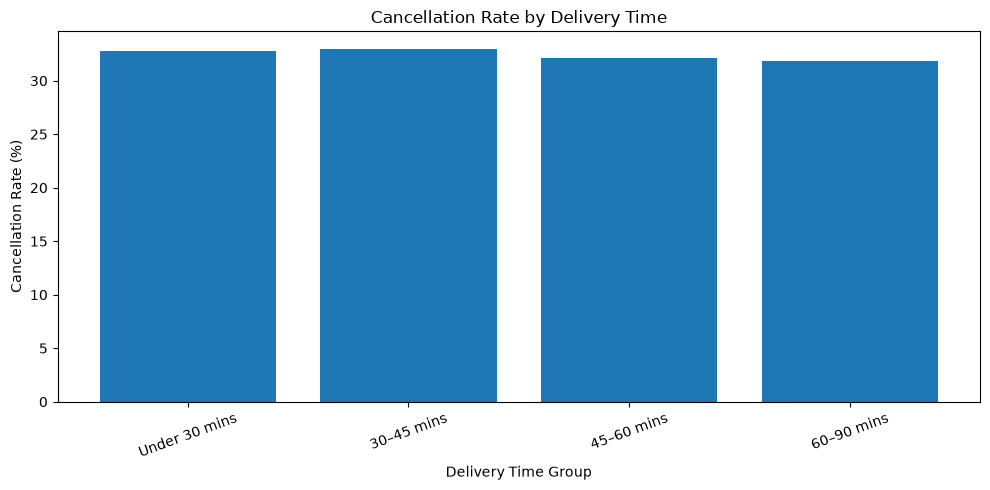

In [63]:
plt.figure(figsize=(10, 5))

plt.bar(
    delivery_cancellation.index,
    delivery_cancellation["Cancellation_Rate"]
)

plt.title("Cancellation Rate by Delivery Time")
plt.xlabel("Delivery Time Group")
plt.ylabel("Cancellation Rate (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [64]:
correlation_columns = [
    "Order Amount (INR)",
    "Delivery Time (mins)",
    "Rating",
    "Number of Items",
    "Delivery Distance (km)",
    "Tip Amount (INR)"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Order Amount (INR),Delivery Time (mins),Rating,Number of Items,Delivery Distance (km),Tip Amount (INR)
Order Amount (INR),1.000000,-0.009151,-0.000013,-0.005272,-0.004542,-0.008007
Delivery Time (mins),-0.009151,1.000000,-0.004451,0.008719,-0.002978,-0.017520
Rating,-0.000013,-0.004451,1.000000,0.020318,0.001631,-0.001528
Number of Items,-0.005272,0.008719,0.020318,1.000000,-0.016868,0.006355
Delivery Distance (km),-0.004542,-0.002978,0.001631,-0.016868,1.000000,-0.015417
Tip Amount (INR),-0.008007,-0.017520,-0.001528,0.006355,-0.015417,1.000000


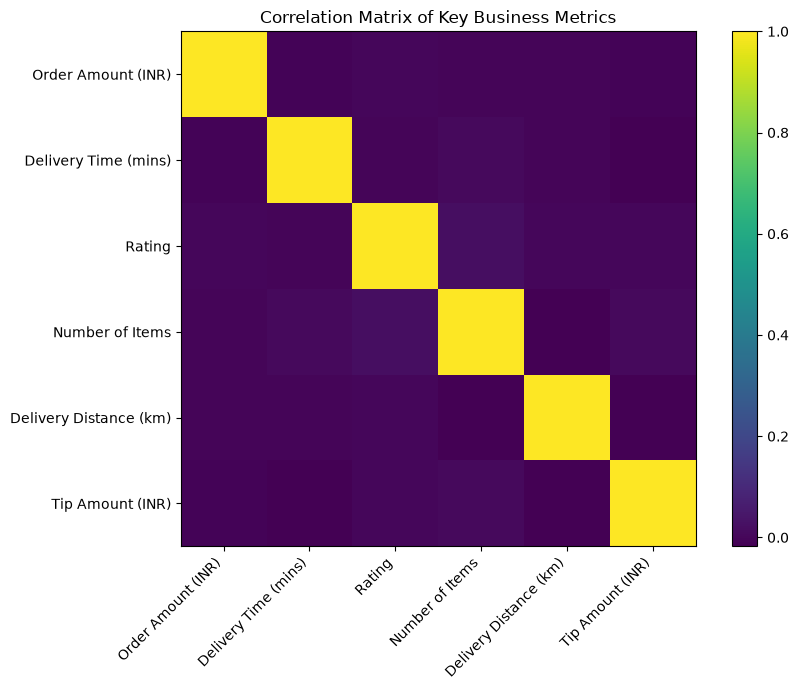

In [65]:
plt.figure(figsize=(9, 7))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Key Business Metrics")

plt.tight_layout()
plt.show()

In [69]:
# Make sure Completed Revenue exists

if "Completed Revenue" not in df.columns:
    df["Completed Revenue"] = np.where(
        df["Order Status"] == "Delivered",
        df["Order Amount (INR)"],
        0
    )

print("Completed Revenue column is ready!")

Completed Revenue column is ready!


In [70]:
# STEP 20: Dashboard Summary Tables

# 1. Overall KPIs
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Revenue",
        "Average Order Value",
        "Average Delivery Time",
        "Average Rating",
        "Total Cancelled Orders"
    ],
    "Value": [
        df["Order ID"].nunique(),
        df["Completed Revenue"].sum(),
        df["Order Amount (INR)"].mean(),
        df["Delivery Time (mins)"].mean(),
        df["Rating"].mean(),
        (df["Order Status"] == "Cancelled").sum()
    ]
})

kpi_summary

,Metric,Value
0,Total Orders,1.000000e+04
1,Total Revenue,6.360494e+06
2,Average Order Value,1.579446e+03
3,Average Delivery Time,4.953737e+01
4,Average Rating,3.003961e+00
5,Total Cancelled Orders,3.838000e+03


In [72]:
# STEP 20.2: Monthly Dashboard Data

# Make sure date column is datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Create Year and Month columns
df["Year"] = df["Order Date"].dt.year
df["Month_Number"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.strftime("%B")

# Create monthly summary
monthly_dashboard = (
    df.groupby(["Year", "Month_Number", "Month_Name"])
    .agg(
        Total_Orders=("Order ID", "nunique"),
        Revenue=("Completed Revenue", "sum"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Avg_Delivery_Time=("Delivery Time (mins)", "mean"),
        Avg_Rating=("Rating", "mean")
    )
    .reset_index()
    .sort_values(["Year", "Month_Number"])
)

monthly_dashboard

,Year,Month_Number,Month_Name,Total_Orders,Revenue,Avg_Order_Value,Avg_Delivery_Time,Avg_Rating
0,2023,1,January,489,264077,1505.167808,48.724315,2.940753
1,2023,2,February,409,289852,1564.861507,49.195519,2.948473
2,2023,3,March,463,293401,1638.848598,49.773832,3.112336
3,2023,4,April,493,266063,1520.103918,48.991482,2.958944
4,2023,5,May,489,360492,1603.525084,49.535117,3.066722
5,2023,6,June,484,296831,1532.969589,50.182469,3.125581
6,2023,7,July,497,327002,1555.743044,50.196399,2.963175
7,2023,8,August,460,314194,1561.387900,48.848754,2.990747
8,2023,9,September,478,290862,1504.048527,49.048527,3.024957
9,2023,10,October,491,284516,1618.457831,48.032702,3.099656


In [73]:
status_dashboard = (
    df.groupby("Order Status")
    .agg(
        Orders=("Order ID", "nunique"),
        Revenue=("Completed Revenue", "sum")
    )
    .reset_index()
)

status_dashboard

,Order Status,Orders,Revenue
0,Cancelled,3219,0
1,Delivered,3399,6360494
2,In-Transit,3382,0


In [74]:
payment_dashboard = (
    df.groupby("Payment Method")
    .agg(
        Total_Orders=("Order ID", "nunique"),
        Revenue=("Completed Revenue", "sum"),
        Avg_Order_Value=("Order Amount (INR)", "mean")
    )
    .reset_index()
)

payment_dashboard

,Payment Method,Total_Orders,Revenue,Avg_Order_Value
0,Cash,2004,1262379,1588.100168
1,Credit Card,1986,1251840,1576.591854
2,Debit Card,1979,1292096,1569.420068
3,Net Banking,1986,1291937,1582.145346
4,UPI,2045,1262242,1580.811492


In [75]:
restaurant_dashboard = (
    df.groupby("name")
    .agg(
        Total_Orders=("Order ID", "nunique"),
        Revenue=("Completed Revenue", "sum"),
        Avg_Order_Value=("Order Amount (INR)", "mean"),
        Avg_Rating=("Rating", "mean")
    )
    .reset_index()
    .sort_values("Total_Orders", ascending=False)
)

restaurant_dashboard.head(10)

,name,Total_Orders,Revenue,Avg_Order_Value,Avg_Rating
1946,Domino's Pizza,62,48110,1558.075758,2.892424
1132,Cafe Coffee Day,51,21819,1534.654545,2.929091
3342,KFC,44,25153,1384.426230,3.050820
6426,Subway,34,18058,1243.500000,3.078261
3520,Keventers,29,25903,1723.125000,2.937500
4172,McDonald's,27,22813,1625.428571,3.402857
709,Baskin Robbins,27,14179,1547.258065,3.125806
1062,Burger King,23,28822,1569.243243,2.835135
5014,Pizza Hut,21,12274,1579.655172,3.382759
6797,The Chocolate Room,18,18102,1537.208333,3.041667


In [76]:
# STEP 20.6: Export Dashboard Data

import os

# Create dashboard folder
os.makedirs("../data/dashboard", exist_ok=True)

# Export summary tables
kpi_summary.to_csv("../data/dashboard/kpi_summary.csv", index=False)
monthly_dashboard.to_csv("../data/dashboard/monthly_dashboard.csv", index=False)
status_dashboard.to_csv("../data/dashboard/status_dashboard.csv", index=False)
payment_dashboard.to_csv("../data/dashboard/payment_dashboard.csv", index=False)
restaurant_dashboard.to_csv("../data/dashboard/restaurant_dashboard.csv", index=False)

print("Dashboard datasets exported successfully!")

Dashboard datasets exported successfully!
